In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler, RobustScaler
from category_encoders import OneHotEncoder, BinaryEncoder, OrdinalEncoder
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.utils import resample
from sklearn.feature_selection import f_classif, chi2
from scipy.stats import spearmanr, chi2_contingency, pointbiserialr

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score

import math
import warnings
warnings.filterwarnings('ignore')

In [23]:
df1 = pd.read_csv('../data/raw/16P.csv' , encoding='latin1')

Data Overiew

In [24]:
df2 = pd.read_csv('../data/raw/Personality classification Data .csv ', encoding='latin1')

In [25]:
df1.shape

(59999, 62)

In [26]:
df2.shape

(122, 30)

Data set1 has more features and rows 

In [27]:
df1.describe().T.style.bar(subset=['mean'], color='#FFA07A').background_gradient(
    subset=['std', '50%', 'max'], cmap='Blues').set_properties(
        **{'font-size': '12pt', 'border': '1.5px solid black'}).set_caption("🔍 Summary Statistics of the Dataset")

,count,mean,std,min,25%,50%,75%,max
Response Id,59999.000000,29999.000000,17320.363738,0.000000,14999.500000,29999.000000,44998.500000,59998.000000
You regularly make new friends.,59999.000000,-0.000867,0.365701,-2.000000,0.000000,0.000000,0.000000,1.000000
You spend a lot of your free time exploring various random topics that pique your interest,59999.000000,-0.000467,0.364652,-1.000000,0.000000,0.000000,0.000000,1.000000
Seeing other people cry can easily make you feel like you want to cry too,59999.000000,0.000267,1.527343,-3.000000,-1.000000,0.000000,1.000000,3.000000
You often make a backup plan for a backup plan.,59999.000000,-0.232887,1.502173,-3.000000,-1.000000,0.000000,1.000000,3.000000
"You usually stay calm, even under a lot of pressure",59999.000000,-0.175653,1.502999,-3.000000,-1.000000,0.000000,1.000000,3.000000
"At social events, you rarely try to introduce yourself to new people and mostly talk to the ones you already know",59999.000000,0.005317,1.521413,-3.000000,-1.000000,0.000000,1.000000,3.000000
You prefer to completely finish one project before starting another.,59999.000000,-0.476558,1.445931,-3.000000,-2.000000,-1.000000,0.000000,3.000000
You are very sentimental.,59999.000000,-0.000550,0.367361,-1.000000,0.000000,0.000000,0.000000,2.000000
You like to use organizing tools like schedules and lists.,59999.000000,0.126819,1.537329,-3.000000,-1.000000,0.000000,1.000000,3.000000


In [28]:
df2.describe().T.style.bar(subset=['mean'], color='#FFA07A').background_gradient(
    subset=['std', '50%', 'max'], cmap='Blues').set_properties(
        **{'font-size': '12pt', 'border': '1.5px solid black'}).set_caption("🔍 Summary Statistics of the Dataset")

,count,mean,std,min,25%,50%,75%,max
Worry about things.,117.000000,-0.623932,1.222818,-2.000000,-1.000000,-1.000000,0.000000,2.000000
Make friends easily.,117.000000,0.700855,0.459853,0.000000,0.000000,1.000000,1.000000,1.000000
Have a vivid imagination.,120.000000,0.641667,0.481521,0.000000,0.000000,1.000000,1.000000,1.000000
Trust others,122.000000,0.786885,0.784451,0.000000,0.000000,1.000000,1.000000,2.000000
Get angry easily.,120.000000,-1.391667,0.584043,-2.000000,-2.000000,-1.000000,-1.000000,0.000000
Love large parties.,122.000000,1.098361,0.673094,0.000000,1.000000,1.000000,2.000000,2.000000
Would never cheat to get ahead.,117.000000,-1.555556,0.499041,-2.000000,-2.000000,-2.000000,-1.000000,-1.000000
Like order.,122.000000,0.786885,0.784451,0.000000,0.000000,1.000000,1.000000,2.000000
Often feel unhappy.,120.000000,0.250000,0.801784,-1.000000,0.000000,0.000000,1.000000,1.000000
Take charge.,122.000000,0.786885,0.784451,0.000000,0.000000,1.000000,1.000000,2.000000


In [29]:
def data_info(data):

  Names = [col for col in data]
  data_types = [data[col].dtype for col in data.columns]
  nunique_Values = [data[col].nunique() for col in data.columns]
  top_10_unique_values = [data[col].value_counts().head(10).index.to_list() for col in data.columns]
  nulls = [data[col].isnull().sum() for col in data.columns]
  percentage_of_nulls = [data[col].isnull().sum() / len(data)*100 for col in data.columns]
  duplicates = data.duplicated().sum()

  info_df = pd.DataFrame({'Names' : Names ,
      'Data_type' : data_types ,
      'Nunique_Values' : nunique_Values ,
      'Top_10_Unique_Values' : top_10_unique_values ,
      'NUlls' : nulls ,
      'Duplicates' : duplicates
                          })
  return info_df

In [30]:
data_info(df1)

,Names,Data_type,Nunique_Values,Top_10_Unique_Values,NUlls,Duplicates
0,Response Id,int64,59999,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]",0,0
1,You regularly make new friends.,int64,4,"[0, -1, 1, -2]",0,0
2,You spend a lot of your free time exploring va...,int64,3,"[0, -1, 1]",0,0
3,Seeing other people cry can easily make you fe...,int64,7,"[0, -1, 1, -2, 2, 3, -3]",0,0
4,You often make a backup plan for a backup plan.,int64,7,"[-1, 0, 1, -2, 2, -3, 3]",0,0
...,...,...,...,...,...,...
57,You are very intrigued by things labeled as co...,int64,4,"[0, 1, -1, -2]",0,0
58,You would pass along a good opportunity if you...,int64,7,"[0, 1, -1, 2, -2, 3, -3]",0,0
59,You struggle with deadlines.,int64,7,"[0, -1, 1, 2, -2, 3, -3]",0,0
60,You feel confident that things will work out f...,int64,7,"[0, 1, -1, 2, -2, 3, -3]",0,0


In [31]:
#Droping irrelevant columns in df1
df3 = df1.drop('Response Id' , axis = 1)

In [33]:
data_info(df3)

,Names,Data_type,Nunique_Values,Top_10_Unique_Values,NUlls,Duplicates
0,You regularly make new friends.,int64,4,"[0, -1, 1, -2]",0,0
1,You spend a lot of your free time exploring va...,int64,3,"[0, -1, 1]",0,0
2,Seeing other people cry can easily make you fe...,int64,7,"[0, -1, 1, -2, 2, 3, -3]",0,0
3,You often make a backup plan for a backup plan.,int64,7,"[-1, 0, 1, -2, 2, -3, 3]",0,0
4,"You usually stay calm, even under a lot of pre...",int64,7,"[0, -1, 1, -2, 2, -3, 3]",0,0
...,...,...,...,...,...,...
56,You are very intrigued by things labeled as co...,int64,4,"[0, 1, -1, -2]",0,0
57,You would pass along a good opportunity if you...,int64,7,"[0, 1, -1, 2, -2, 3, -3]",0,0
58,You struggle with deadlines.,int64,7,"[0, -1, 1, 2, -2, 3, -3]",0,0
59,You feel confident that things will work out f...,int64,7,"[0, 1, -1, 2, -2, 3, -3]",0,0


In [34]:
data_info(df2)

,Names,Data_type,Nunique_Values,Top_10_Unique_Values,NUlls,Duplicates
0,Worry about things.,float64,4,"[-1.0, -2.0, 2.0, 0.0]",5,52
1,Make friends easily.,float64,2,"[1.0, 0.0]",5,52
2,Have a vivid imagination.,float64,2,"[1.0, 0.0]",2,52
3,Trust others,int64,3,"[0, 1, 2]",0,52
4,Get angry easily.,float64,3,"[-1.0, -2.0, 0.0]",2,52
5,Love large parties.,int64,3,"[1, 2, 0]",0,52
6,Would never cheat to get ahead.,float64,2,"[-2.0, -1.0]",5,52
7,Like order.,int64,3,"[0, 1, 2]",0,52
8,Often feel unhappy.,float64,3,"[1.0, 0.0, -1.0]",2,52
9,Take charge.,int64,3,"[0, 1, 2]",0,52



**Data Overview:** 
1. Shape of the data :
     df1 has 59999 rows, 62 columns
     df2 has 122 rows and 29 columns
2. Duplicates and null: 
     df1 has no duplicates nor nulls 
     df2 has 52 duplicated rows and some features has nulls 
3. No outliers in both data 
4. Target Variable: 
     df1 
     In df2 target feature is not exit
6. In df2 all features all numericals while in df2 the target is str
---

## Analysis and Visualization to get information about the data

### **Graphs**

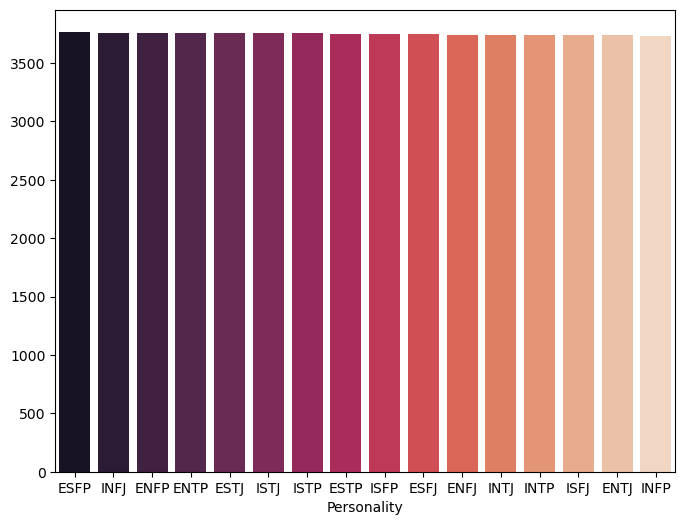

In [38]:
Personality_counts = df1['Personality'].value_counts()
plt.figure(figsize = (8,6))

ax = sns.barplot(
    x = Personality_counts.index ,
    y = Personality_counts.values , 
    palette = 'rocket'
)


**Graph Insights:**
All values in the target almost has the same values 

In [48]:
import joblib

joblib.dump(df3, '../data/processed/df.pkl')

['../data/processed/df.pkl']